In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '..')

from utils.models import CNNLSTM
from utils.preprocessing import normalize_label_name, load_and_preprocess_data
from utils.evaluation import (
    evaluate_model,
    load_and_evaluate_rf_model,
    load_and_evaluate_cnnlstm_model,
)
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

## Preprocess data

In [2]:
df_cicids2017 = load_and_preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_ciciot2023 = load_and_preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")
dataframes = [df_cicids2017, df_ciciot2023]

In [3]:
for df in dataframes:
    for col in [
        "duration",
        "orig_bytes",
        "resp_bytes",
        "missed_bytes",
        "orig_pkts",
        "orig_ip_bytes",
        "resp_pkts",
        "resp_ip_bytes",
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    duration_safe = df["duration"].replace(0, 1e-6)

    df["orig_pkt_rate"] = df["orig_pkts"] / duration_safe
    df["orig_byte_rate"] = df["orig_bytes"] / duration_safe
    df["pkt_asymmetry"] = df["orig_pkts"] / (df["resp_pkts"] + 1.0)
    df["byte_asymmetry"] = df["orig_bytes"] / (df["resp_bytes"] + 1.0)

In [4]:
label_column = "label"

df_cicids2017 = df_cicids2017[df_cicids2017["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]
df_ciciot2023 = df_ciciot2023[df_ciciot2023["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]

X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (481829, 26)
CICIoT test shape: (1850844, 26)


## Load Models

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_27432\3351207930.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_test.select_dtypes(include=["object"]).columns



CICIDS2017-trained RF model tested on CICIoT2023
Accuracy: 0.1850

=== CICIDS2017-trained RF on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1849    1.0000    0.3121    342255
DOS_HTTP_FLOOD     0.9613    0.0001    0.0002   1508589

      accuracy                         0.1850   1850844
     macro avg     0.5731    0.5000    0.1562   1850844
  weighted avg     0.8177    0.1850    0.0579   1850844


=== Per-Label Accuracy ===

BENIGN: 1.0000
DOS_HTTP_FLOOD: 0.0001


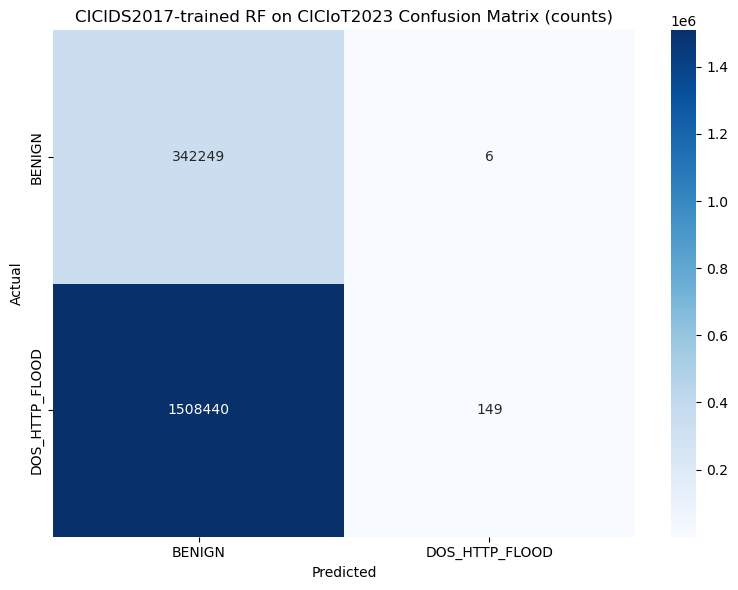

{'BENIGN': {'precision': 0.18493058531174064,
  'recall': 0.9999824692115528,
  'f1-score': 0.3121365616267447,
  'support': 342255.0},
 'DOS_HTTP_FLOOD': {'precision': 0.9612903225806452,
  'recall': 9.87677889736701e-05,
  'f1-score': 0.00019751528423642446,
  'support': 1508589.0},
 'accuracy': 0.18499560200643597,
 'macro avg': {'precision': 0.5731104539461929,
  'recall': 0.5000406185002633,
  'f1-score': 0.15616703845549057,
  'support': 1850844.0},
 'weighted avg': {'precision': 0.817727168755164,
  'recall': 0.18499560200643597,
  'f1-score': 0.0578807659017683,
  'support': 1850844.0}}

In [5]:
# Test CICIDS2017-trained RF model on CICIoT2023
joblib_object = joblib.load("models/random_forest_cicids2017.joblib")
model = joblib_object["model"]
encoder = joblib_object.get("encoder")

X_test = X_ciciot.copy()
categorical_cols = X_test.select_dtypes(include=["object"]).columns
if encoder is not None and len(categorical_cols) > 0:
    X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_ciciot.values)

print(f"\nCICIDS2017-trained RF model tested on CICIoT2023")
print(f"Accuracy: {accuracy:.4f}")
evaluate_model(y_ciciot, y_pred, "CICIDS2017-trained RF on CICIoT2023")

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_16084\2768775254.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_test.select_dtypes(include=["object"]).columns



CICIoT2023-trained RF model tested on CICIDS2017
Accuracy: 0.8271

=== CICIoT2023-trained RF on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.8391    0.9221    0.8786    327060
DOS_HTTP_FLOOD     0.7918    0.6263    0.6994    154769

      accuracy                         0.8271    481829
     macro avg     0.8155    0.7742    0.7890    481829
  weighted avg     0.8239    0.8271    0.8211    481829


=== Per-Label Accuracy ===

BENIGN: 0.9221
DOS_HTTP_FLOOD: 0.6263


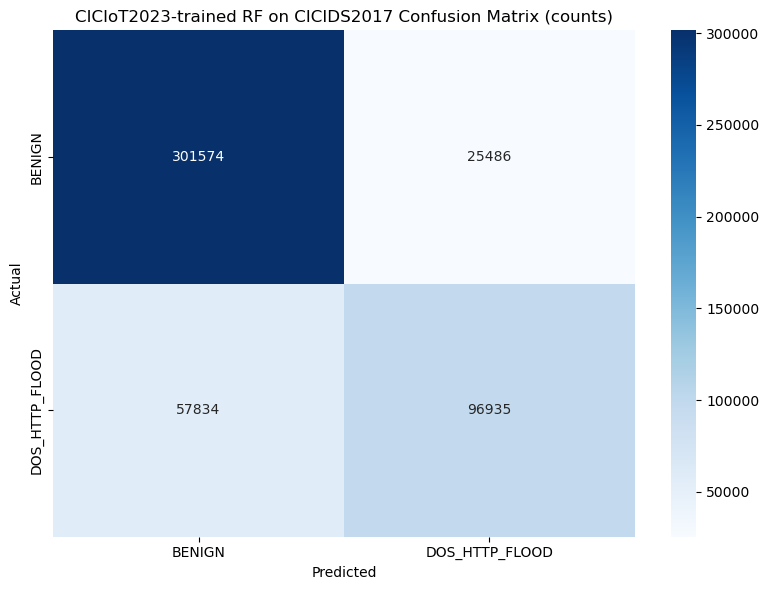

{'BENIGN': {'precision': 0.8390853848550951,
  'recall': 0.9220754601602152,
  'f1-score': 0.8786250779351696,
  'support': 327060.0},
 'DOS_HTTP_FLOOD': {'precision': 0.7918167634637848,
  'recall': 0.6263205163824797,
  'f1-score': 0.6994119556982575,
  'support': 154769.0},
 'accuracy': 0.8270755807558283,
 'macro avg': {'precision': 0.81545107415944,
  'recall': 0.7741979882713474,
  'f1-score': 0.7890185168167136,
  'support': 481829.0},
 'weighted avg': {'precision': 0.8239021616283659,
  'recall': 0.8270755807558283,
  'f1-score': 0.8210597680109338,
  'support': 481829.0}}

In [ ]:
# Test CICIoT2023-trained RF model on CICIDS2017
joblib_object = joblib.load("models/random_forest_ciciot2023.joblib")
model = joblib_object["model"]
encoder = joblib_object.get("encoder")

X_test = X_cicids.copy()
categorical_cols = X_test.select_dtypes(include=["object"]).columns
if encoder is not None and len(categorical_cols) > 0:
    X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_cicids.values)

print(f"\nCICIoT2023-trained RF model tested on CICIDS2017")
print(f"Accuracy: {accuracy:.4f}")
evaluate_model(y_cicids, y_pred, "CICIoT2023-trained RF on CICIDS2017")

Evaluation for CICIoT2023-trained CNN-LSTM on CICIDS2017:

=== CICIoT2023-trained CNN-LSTM on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.6811    0.9663    0.7990    327060
DOS_HTTP_FLOOD     0.3824    0.0441    0.0791    154769

      accuracy                         0.6701    481829
     macro avg     0.5317    0.5052    0.4391    481829
  weighted avg     0.5852    0.6701    0.5678    481829


=== Per-Label Accuracy ===

BENIGN: 0.9663
DOS_HTTP_FLOOD: 0.0441


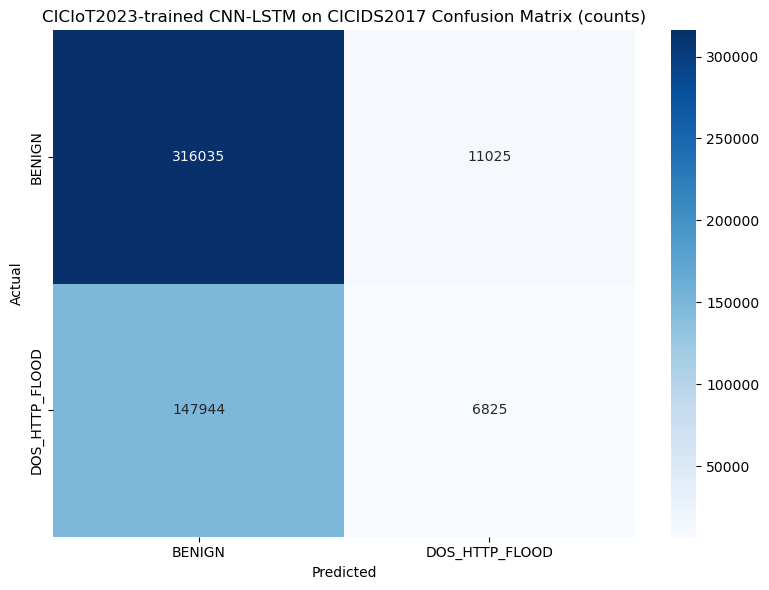

{'predictions': array(['BENIGN', 'BENIGN', 'BENIGN', ..., 'BENIGN', 'BENIGN', 'BENIGN'],
       shape=(481829,), dtype=object),
 'confusion_matrix': array([[316035,  11025],
        [147944,   6825]]),
 'accuracy': np.float64(0.6700717474456706),
 'classification_report': {'BENIGN': {'precision': 0.6811407412835495,
   'recall': 0.9662905888827737,
   'f1-score': 0.7990377212754365,
   'support': 327060.0},
  'DOS_HTTP_FLOOD': {'precision': 0.38235294117647056,
   'recall': 0.04409797827730359,
   'f1-score': 0.07907588388300245,
   'support': 154769.0},
  'accuracy': 0.6700717474456706,
  'macro avg': {'precision': 0.53174684123001,
   'recall': 0.5051942835800387,
   'f1-score': 0.4390568025792195,
   'support': 481829.0},
  'weighted avg': {'precision': 0.5851666736479932,
   'recall': 0.6700717474456706,
   'f1-score': 0.5677777232026978,
   'support': 481829.0}}}

In [6]:
# Test CICIoT2023-trained CNN-LSTM model on CICIDS2017
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNN-LSTM on CICIDS2017"
)

Evaluation for CICIDS2017-trained CNN-LSTM on CICIoT2023:

=== CICIDS2017-trained CNN-LSTM on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.2015    0.9698    0.3337    342255
DOS_HTTP_FLOOD     0.9492    0.1283    0.2260   1508589

      accuracy                         0.2839   1850844
     macro avg     0.5754    0.5490    0.2798   1850844
  weighted avg     0.8110    0.2839    0.2459   1850844


=== Per-Label Accuracy ===

BENIGN: 0.9698
DOS_HTTP_FLOOD: 0.1283


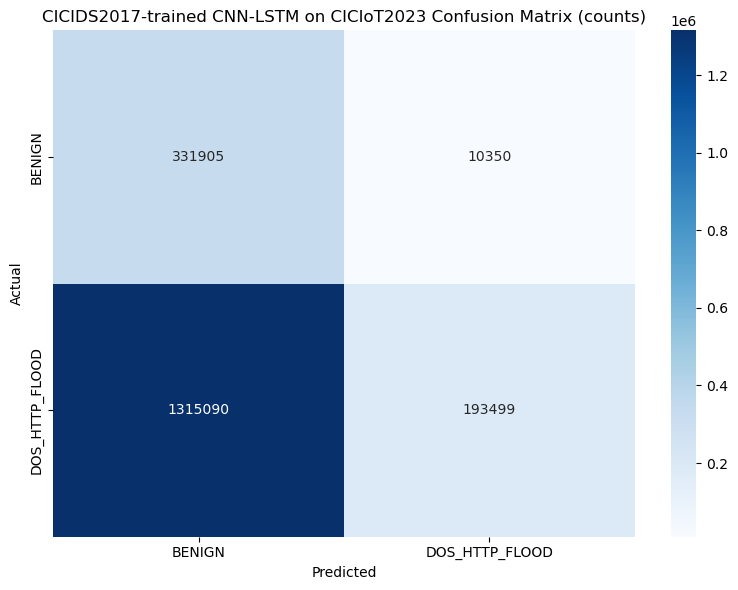

{'predictions': array(['BENIGN', 'BENIGN', 'BENIGN', ..., 'BENIGN', 'BENIGN', 'BENIGN'],
       shape=(1850844,), dtype=object),
 'confusion_matrix': array([[ 331905,   10350],
        [1315090,  193499]]),
 'accuracy': np.float64(0.2838726548536776),
 'classification_report': {'BENIGN': {'precision': 0.2015215589604097,
   'recall': 0.969759389928562,
   'f1-score': 0.3336986301369863,
   'support': 342255.0},
  'DOS_HTTP_FLOOD': {'precision': 0.9492271239986461,
   'recall': 0.1282648885813167,
   'f1-score': 0.22599241549183094,
   'support': 1508589.0},
  'accuracy': 0.2838726548536776,
  'macro avg': {'precision': 0.5753743414795279,
   'recall': 0.5490121392549394,
   'f1-score': 0.2798455228144086,
   'support': 1850844.0},
  'weighted avg': {'precision': 0.8109626521349118,
   'recall': 0.2838726548536776,
   'f1-score': 0.24590926990710185,
   'support': 1850844.0}}}

In [7]:
# Test CICIDS2017-trained CNN-LSTM model on CICIoT2023
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNN-LSTM on CICIoT2023"
)